# Example: WO3 deposited on Si substrate with low SNR

In this example, we will demonstrate Raman spectrum fitting for WO3 deposited on a Si substrate. The Raman spectrum of WO3 typically exhibits characteristic peaks that can be modeled using Lorentzian functions. We will use the `RamanFit` class from the `RamanPL_2D` package to perform the fitting, including background subtraction and peak fitting.

Basic RamanFit usage for WO3 Raman spectrum fitting with raw data provided in `data/WO3_on_Si.txt`.

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\baselineAPI.py:355: RuntimeWarning: overflow encountered in exp
  w = 1.0 / (1.0 + np.exp(2.0 * (d - (2.0 * sigma - mu)) / sigma))


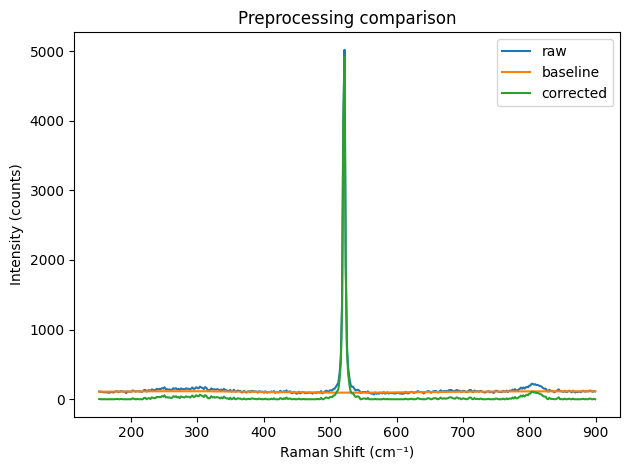


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
O-W-O bending1       259.00          44.77         23.80          22.39     
O-W-O bending2       300.00          44.36         42.60          22.18     
O-W-O stretching1    700.00          42.15         11.21          21.08     
O-W-O stretching2    804.00          24.37         102.47         12.19     
h-WO3 W-OH bending   382.01          0.04          7.36           0.02      
m-WO3 W-OH bending   434.09          1.12          20.99          0.56      
Si                   520.78          3.29          4955.79        1.64      

Normalized Residual: 0.0015 (0 = perfect fit)


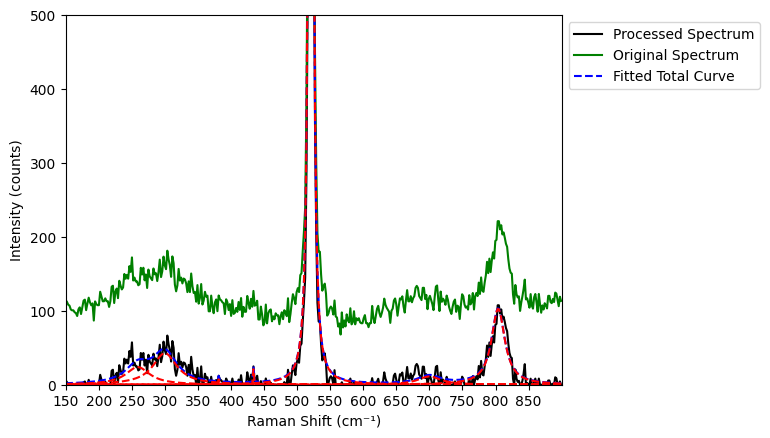

In [1]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='WO3_on_Si.txt',
    x_range=(150, 900)    # Specify the x-axis range to read (in cm^-1)
)

# Baseline settings
baseline_setting={"method": "arpls", "lam": 1e6, "niter": 50, "tol": 1e-6}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(spectra, wavenumber,
                    materials=['WO3'],         # Load materials, if no materials are provided, then WO3 is fitted
                    substrate='Si',            # Default substrate is Si (SiO2 and Si are )
                    normalize=False,            # Normalize your peak intensity
                    background_remove=True,   # If you Raman contains slanted intensity, use this, otherwise no
                    baseline_method=baseline_setting,
                    smoothing=False            # Smooth too noisy signal, only if needed 
                    )

# Update the fitting bounds 
bounds_dict = {
    'O-W-O bending1': ([259, 0, 0], [270, 30, 10]),
    'O-W-O bending2'   :   ([280, 0, 0], [300, 30, 10]),
    'O-W-O stretching1'    :   ([700, 0, 0], [710, 30, 10]),
    'O-W-O stretching2'      :   ([800, 0, 0], [804, 25, 20])
}
raman_fit.update_bounds(**bounds_dict) 

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [150, 900]
raman_fit.plot_fit(params,                      # The Lorentzian parameters fitted 
                   offset=0, scale=1,           # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,500],  # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],50)
                   )

The above cell shows that due to low signal response from WO3 Raman peaks, the fitted peaks may not align well with the actual data. To improve the fitting accuracy, we can do arithmetic background subtraction before fitting. The cell below demonstrates how to implement this using the `RamanFit` class with background removal enabled.

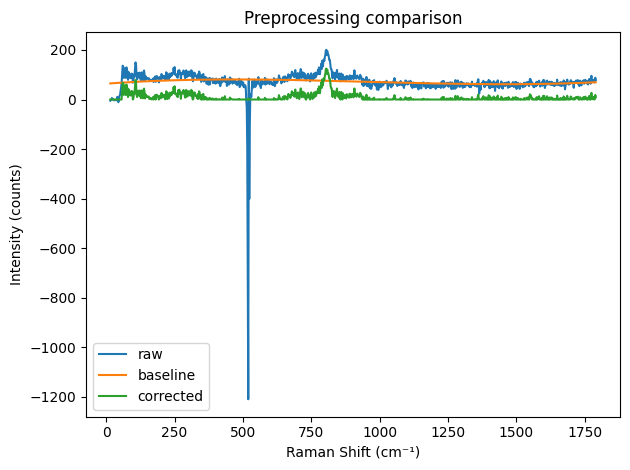


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
O-W-O bending1       259.00          53.15         14.92          26.58     
O-W-O bending2       292.95          57.38         13.83          28.69     
O-W-O stretching1    710.00          57.19         13.88          28.59     
O-W-O stretching2    804.00          16.03         98.22          8.02      
h-WO3 W-OH bending   365.00          20.00         4.51           10.00     
m-WO3 W-OH bending   433.97          0.14          12.07          0.07      

Normalized Residual: 0.4337 (0 = perfect fit)


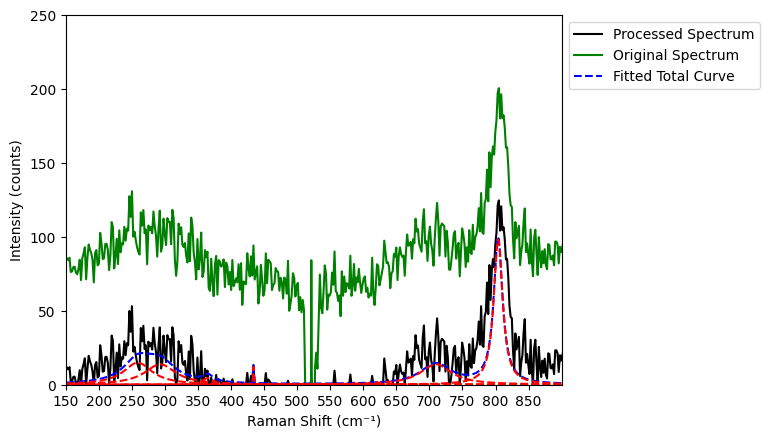

In [2]:
from ramanpl.operation import ArithmeticSpectrum
from ramanpl import RamanFit

yC, xC = ArithmeticSpectrum.combine(
    "WO3_on_Si.txt",
    "Si_ref.txt",
    op="sub",
    k=0.7375,                   # scaling factor for the reference spectrum
    axis="wavenumber",
    save=True,                  # save the background removed spectrum
    out_path="WO3_rm bg.txt"    # output path/save name, if save=True, it must be provided
)

# Baseline settings
baseline_setting={"method": "poly", "degree": 3}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(yC, xC,
                    materials=['WO3'],          # Load materials, if no materials are provided, then WO3 is fitted
                    substrate='Si',             # Default substrate is Si (SiO2 and Si are )
                    normalize=False,             # Normalize your peak intensity
                    background_remove=True,     # If you Raman contains slanted intensity, use this, otherwise no
                    baseline_method=baseline_setting,
                    smoothing=False,            # Smooth too noisy signal, only if needed 
                    )

# Update the fitting bounds 
bounds_dict = {
    'O-W-O bending1': ([259, 0, 0], [270, 30, 10]),
    'O-W-O bending2'   :   ([280, 0, 0], [300, 30, 10]),
    'O-W-O stretching1'    :   ([700, 0, 0], [710, 30, 10]),
    'O-W-O stretching2'      :   ([800, 0, 0], [804, 25, 20])
}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('Si') 

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [150, 900]
raman_fit.plot_fit(params,                      # The Lorentzian parameters fitted 
                   offset=0, scale=1,           # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,250],  # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],50)
                   )
